# Лабораторная 4. Элементарный перцептрон. Ансамбль элементарных перцептронов

**Задание 9.** Реализовать программно алгоритм обучения элементарного
перцептрона для распознавания растровых изображений. Варианты реализации:
а) 10 элементарных перцептронов, классифицирующих цифры как цифры двух классов
(эта цифра / другая цифра); б) один перцептрон, вместо ступенчатой функции
использующий в качестве функции активации функцию мягкого максимума, обучаемый
с помощью стохастического градиентного спуска.

**Задание 10.** Сформировать ансамбль из обученных элементарных перцептронов.
Сравнить для одной и той же выборки результаты классификации растровых
изображений с результатами, полученными методом ближайшего соседа, и с помощью
отдельного классификатора из предыдущего задания.

## 1. Теория

### Элементарный перцептрон

Перцептрон вычисляет $y(x) = \theta(\langle w, x\rangle)$, где $\theta$ -
ступенчатая функция, а свободный член внесён в $w$ добавлением к $x$ единичной
компоненты. Уравнение $\langle w, x\rangle = 0$ задаёт гиперплоскость, и
перцептрон относит объект к классу по тому, с какой стороны от неё объект лежит.

Алгоритм обучения: элементы выборки предъявляются циклически; если объект
классифицирован верно, веса не меняются, иначе

$$w \leftarrow w + \eta\,x \ \ (x \in \mathcal{H}_1),
\qquad w \leftarrow w - \eta\,x \ \ (x \in \mathcal{H}_2).$$

По теореме о сходимости для линейно отделимых классов алгоритм останавливается
за конечное число коррекций, не превосходящее $\beta\lVert\tilde w\rVert^2/\alpha^2$.

### Что делать с линейно неотделимой выборкой

Цифры MNIST линейно неотделимы, поэтому алгоритм не сойдётся: веса будут
колебаться бесконечно. Используется приём «карман» (pocket): в ходе обучения
запоминаются веса, давшие наилучшую точность на обучающей выборке, и по
исчерпании лимита эпох возвращаются именно они. Без этого результат зависел бы
от того, на каком объекте обучение прервали.

### Вариант а: десять бинарных перцептронов

Для каждой цифры $c$ обучается свой перцептрон, отделяющий класс «это $c$» от
класса «любая другая цифра». Предсказание для нового объекта берётся по
максимуму линейной оценки:

$$\hat y(x) = \arg\max_c \langle w_c, x\rangle .$$

Голосование по знакам $\theta(\langle w_c, x\rangle)$ работает хуже, потому что
даёт много неразрешимых ситуаций: сразу несколько перцептронов отвечают «да»
либо все отвечают «нет». Сравним оба способа.

### Вариант б: softmax и стохастический градиентный спуск

Один классификатор с матрицей весов $W$ размера $10 \times m$ выдаёт
распределение вероятностей

$$p_c(x) = \frac{e^{\langle w_c, x\rangle}}{\sum_{j} e^{\langle w_j, x\rangle}},$$

и обучается минимизацией перекрёстной энтропии
$L = -\sum_k \log p_{y_k}(x_k)$. Градиент по $W$ имеет простой вид

$$\nabla_{w_c} L = \sum_k \bigl(p_c(x_k) - [\,y_k = c\,]\bigr)\,x_k,$$

и обновление весов делается по мини-батчам. В отличие от ступенчатой функции
softmax дифференцируем, поэтому есть градиент и обучение не требует линейной
отделимости.

### Ансамбль

Ансамбль строится бэггингом: несколько наборов бинарных перцептронов обучаются
на бутстрап-подвыборках, с разным порядком предъявления и разными коэффициентами
обучения, а их линейные оценки усредняются. Разнообразие базовых классификаторов
берётся из того, что перцептрон на неотделимой выборке сильно зависит от порядка
предъявления - это ровно то свойство, которое разбиралось в задании 1 задачи 4.

## 2. Данные

In [1]:
import os
import struct
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110


def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def mnist_dir():
    for c in [os.environ.get('MNIST_DIR'),
              '../../bachelor/Perceptron/data_generation/MNIST/raw',
              'data/MNIST/raw']:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError('не найдены файлы MNIST')


D = mnist_dir()


def stratified(X, y, per_class, rng):
    idx = np.concatenate([rng.choice(np.flatnonzero(y == c), per_class, replace=False)
                          for c in range(10)])
    rng.shuffle(idx)
    return X[idx], y[idx]


X_tr_img, y_tr = stratified(read_idx(D / 'train-images-idx3-ubyte'),
                            read_idx(D / 'train-labels-idx1-ubyte'), 200, RNG)
X_te_img, y_te = stratified(read_idx(D / 't10k-images-idx3-ubyte'),
                            read_idx(D / 't10k-labels-idx1-ubyte'), 30, RNG)


def flatten(X):
    flat = X.reshape(len(X), -1).astype(np.float32) / 255.0
    return np.hstack([flat, np.ones((len(flat), 1), dtype=np.float32)])


X_tr, X_te = flatten(X_tr_img), flatten(X_te_img)
print(f'обучающая {X_tr.shape}, тестовая {X_te.shape}')
print('выборка та же, что в лабораторной 1: те же зерно и процедура отбора')

обучающая (2000, 785), тестовая (300, 785)
выборка та же, что в лабораторной 1: те же зерно и процедура отбора


Последняя компонента вектора признаков равна единице и отвечает за свободный
член. Выборка совпадает с использованной в лабораторной 1, поэтому результаты
напрямую сравнимы.

## 3. Вариант а: десять бинарных перцептронов

In [2]:
def train_perceptron(X, t, eta, epochs, rng, shuffle=True):
    """Обучение элементарного перцептрона с приёмом pocket.
    t - метки из {-1, +1}. Возвращает лучшие веса и историю точности."""
    w = np.zeros(X.shape[1], dtype=np.float32)
    best_w, best_acc, history = w.copy(), -1.0, []
    order = np.arange(len(X))
    for _ in range(epochs):
        if shuffle:
            rng.shuffle(order)
        for i in order:
            if t[i] * (X[i] @ w) <= 0:
                w += eta * t[i] * X[i]
        acc = float(np.mean(np.sign(X @ w) == t))
        history.append(acc)
        if acc > best_acc:
            best_acc, best_w = acc, w.copy()
    return best_w, np.array(history)


def train_ovr(X, y, eta=0.1, epochs=30, rng=None, shuffle=True):
    """Десять перцептронов эта цифра / другая цифра."""
    rng = rng or np.random.default_rng(0)
    W = np.zeros((10, X.shape[1]), dtype=np.float32)
    hist = []
    for c in range(10):
        t = np.where(y == c, 1.0, -1.0).astype(np.float32)
        W[c], h = train_perceptron(X, t, eta, epochs, rng, shuffle)
        hist.append(h)
    return W, np.array(hist)

In [3]:
t0 = time.time()
W_ovr, hist_ovr = train_ovr(X_tr, y_tr, eta=0.1, epochs=30,
                            rng=np.random.default_rng(1))
t_ovr = time.time() - t0

pred_argmax = (X_te @ W_ovr.T).argmax(1)
signs = np.sign(X_te @ W_ovr.T)
n_yes = (signs > 0).sum(1)
pred_vote = np.where(n_yes == 1, signs.argmax(1), (X_te @ W_ovr.T).argmax(1))

print(f'обучение 10 перцептронов: {t_ovr:.1f} с')
print(f'accuracy по argmax оценки:      {np.mean(pred_argmax == y_te):.4f}')
print(f'accuracy по голосованию знаков: {np.mean(pred_vote == y_te):.4f}')
print(f'ровно один перцептрон ответил да: {np.mean(n_yes == 1):.1%} объектов')
print(f'ни один не ответил да:            {np.mean(n_yes == 0):.1%}')
print(f'больше одного ответили да:        {np.mean(n_yes > 1):.1%}')

обучение 10 перцептронов: 1.6 с
accuracy по argmax оценки:      0.8467
accuracy по голосованию знаков: 0.8467
ровно один перцептрон ответил да: 74.7% объектов
ни один не ответил да:            8.7%
больше одного ответили да:        16.7%


Точность $0.847$. Голосование по знакам однозначно разрешает только $74.7\%$
объектов: на $16.7\%$ сразу несколько перцептронов отвечают «да», на $8.7\%$ не
отвечает ни один. На этих объектах всё равно приходится обращаться к максимуму
линейной оценки, поэтому итоговая точность у обоих способов совпадает. Наличие
четверти неразрешимых случаев и есть причина, по которой схему «эта цифра /
другая цифра» со ступенчатой функцией на практике заменяют сравнением оценок.

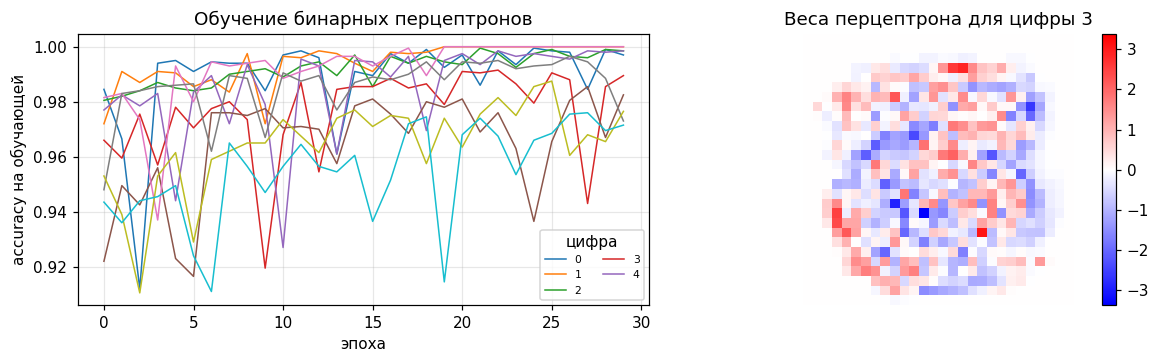

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for c in range(10):
    axes[0].plot(hist_ovr[c], lw=1, label=str(c) if c < 5 else None)
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('accuracy на обучающей')
axes[0].set_title('Обучение бинарных перцептронов')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=7, ncol=2, title='цифра')

im = axes[1].imshow(W_ovr[3, :-1].reshape(28, 28), cmap='bwr',
                    vmin=-np.abs(W_ovr[3, :-1]).max(), vmax=np.abs(W_ovr[3, :-1]).max())
axes[1].set_title('Веса перцептрона для цифры 3')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

Кривые обучения не выходят на плато и колеблются от эпохи к эпохе: выборка
линейно неотделима, теорема о сходимости неприменима, и алгоритм не
останавливается. Именно поэтому нужен приём pocket - без него результат зависел
бы от того, на какой эпохе обучение прервали.

Карта весов не случайна: положительные и отрицательные области складываются в
узнаваемый шаблон, где красным отмечены пиксели, наличие чернил в которых
говорит за цифру 3, а синим - против.

## 4. Вариант б: softmax и стохастический градиентный спуск

In [5]:
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def train_softmax(X, y, eta=0.5, epochs=60, batch=32, rng=None):
    """Один перцептрон с мягким максимумом, обучение по мини-батчам."""
    rng = rng or np.random.default_rng(0)
    W = np.zeros((10, X.shape[1]), dtype=np.float32)
    Y = np.eye(10, dtype=np.float32)[y]
    hist = []
    idx = np.arange(len(X))
    for _ in range(epochs):
        rng.shuffle(idx)
        for s in range(0, len(X), batch):
            b = idx[s:s + batch]
            P = softmax(X[b] @ W.T)
            W -= eta * ((P - Y[b]).T @ X[b]) / len(b)
        P = softmax(X @ W.T)
        loss = float(-np.mean(np.log(P[np.arange(len(y)), y] + 1e-12)))
        hist.append((loss, float(np.mean(P.argmax(1) == y))))
    return W, np.array(hist)

обучение softmax: 0.4 с
accuracy: 0.8633


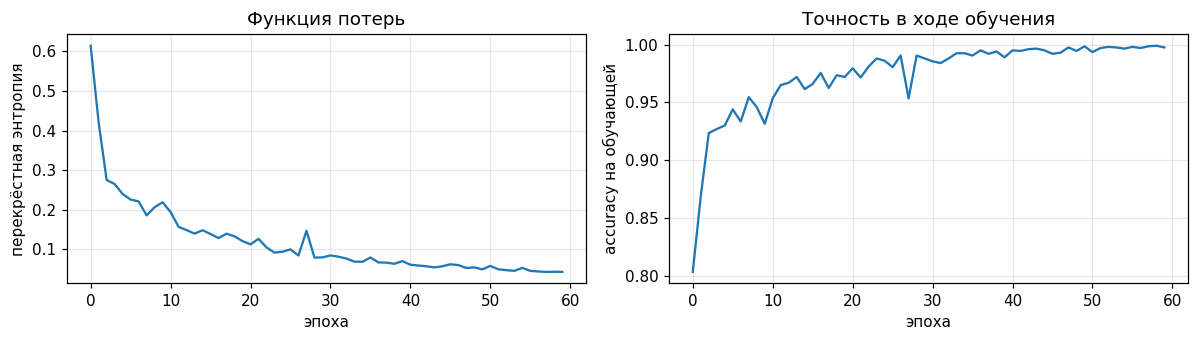

In [6]:
t0 = time.time()
W_soft, hist_soft = train_softmax(X_tr, y_tr, eta=0.5, epochs=60, batch=32,
                                  rng=np.random.default_rng(2))
t_soft = time.time() - t0
pred_soft = (X_te @ W_soft.T).argmax(1)
print(f'обучение softmax: {t_soft:.1f} с')
print(f'accuracy: {np.mean(pred_soft == y_te):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(hist_soft[:, 0])
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('перекрёстная энтропия')
axes[0].set_title('Функция потерь'); axes[0].grid(alpha=0.3)
axes[1].plot(hist_soft[:, 1])
axes[1].set_xlabel('эпоха'); axes[1].set_ylabel('accuracy на обучающей')
axes[1].set_title('Точность в ходе обучения'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Softmax обучается за $0.4$ с и даёт $0.863$ против $0.847$ у десяти
перцептронов. Функция потерь убывает монотонно: в отличие от ступенчатой
активации здесь есть градиент, и линейная неотделимость не мешает, поскольку
минимизируется не само число ошибок, а гладкая верхняя оценка для него.

In [7]:
rows = []
for eta in [0.01, 0.05, 0.1, 0.5]:
    for epochs in [10, 30, 60]:
        W, _ = train_softmax(X_tr, y_tr, eta=eta, epochs=epochs, batch=32,
                             rng=np.random.default_rng(2))
        rows.append(dict(model='softmax', eta=eta, epochs=epochs,
                         accuracy=float(np.mean((X_te @ W.T).argmax(1) == y_te))))
    for epochs in [10, 30]:
        W, _ = train_ovr(X_tr, y_tr, eta=eta, epochs=epochs,
                         rng=np.random.default_rng(1))
        rows.append(dict(model='10 перцептронов', eta=eta, epochs=epochs,
                         accuracy=float(np.mean((X_te @ W.T).argmax(1) == y_te))))

grid = pd.DataFrame(rows)
grid.pivot_table(index=['model', 'eta'], columns='epochs', values='accuracy').round(4)

epochs                    10      30      60
model           eta                         
10 перцептронов 0.01  0.8567  0.8467     NaN
                0.05  0.8567  0.8467     NaN
                0.10  0.8567  0.8467     NaN
                0.50  0.8567  0.8467     NaN
softmax         0.01  0.8467  0.8600  0.8700
                0.05  0.8667  0.8867  0.8833
                0.10  0.8800  0.8800  0.8833
                0.50  0.8700  0.8700  0.8633

Главное наблюдение в таблице: у десяти перцептронов точность **не зависит от
коэффициента обучения вообще** - ровно $0.8567$ при 10 эпохах и ровно $0.8467$
при 30 для всех четырёх значений $\eta$ от $0.01$ до $0.5$.

Это прямое подтверждение результата задания 2 задачи 4: при $w(0) = 0$ веса
масштабируются как $w_\eta(n) = \eta\,w_1(n)$, а проверка
$\langle w, x\rangle > 0$ от положительного множителя не зависит, поэтому вся
последовательность решений алгоритма одна и та же при любом $\eta$.

У softmax зависимость от $\eta$ есть и заметная, от $0.8467$ до $0.8867$: там
обновление градиентное, и величина шага меняет траекторию.

Второе наблюдение: у перцептронов 30 эпох хуже 10. Pocket выбирает веса по
точности на обучающей выборке, а она с ростом числа эпох начинает расходиться с
точностью на тестовой.

## 5. Задание 10: ансамбль элементарных перцептронов

In [8]:
def train_ensemble(X, y, size=15, rng=None):
    """Бэггинг: наборы перцептронов на бутстрап-подвыборках с разными eta."""
    rng = rng or np.random.default_rng(0)
    members = []
    for m in range(size):
        idx = rng.integers(0, len(X), len(X))
        eta = float(rng.choice([0.02, 0.05, 0.1, 0.3]))
        W, _ = train_ovr(X[idx], y[idx], eta=eta, epochs=15, rng=rng)
        members.append(W)
    return members


def ensemble_scores(members, X):
    return np.mean([X @ W.T for W in members], axis=0)

In [9]:
t0 = time.time()
members = train_ensemble(X_tr, y_tr, size=15, rng=np.random.default_rng(5))
t_ens = time.time() - t0

pred_ens = ensemble_scores(members, X_te).argmax(1)
single = [float(np.mean((X_te @ W.T).argmax(1) == y_te)) for W in members]

print(f'обучение ансамбля из 15 наборов: {t_ens:.1f} с')
print(f'точность отдельных членов: от {min(single):.4f} до {max(single):.4f}, '
      f'в среднем {np.mean(single):.4f}')
print(f'точность ансамбля: {np.mean(pred_ens == y_te):.4f}')

обучение ансамбля из 15 наборов: 11.8 с
точность отдельных членов: от 0.8200 до 0.8767, в среднем 0.8400
точность ансамбля: 0.8567


Отдельные члены ансамбля дают от $0.820$ до $0.877$ при среднем $0.840$: разброс
в $5.7$ процентных пункта возникает только из-за разного порядка предъявления,
бутстрапа и $\eta$. Ансамбль даёт $0.857$, то есть на $1.7$ пункта выше среднего
члена, но на $2$ пункта ниже лучшего.

Это типичное поведение бэггинга: усреднение снижает дисперсию, но не может
преодолеть общее для всех членов смещение. Все члены остаются линейными
классификаторами по исходным пикселям, и их усреднение - тоже линейный
классификатор.

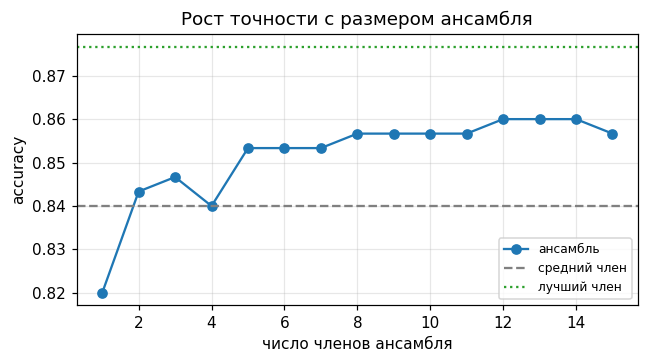

In [10]:
sizes = range(1, 16)
curve = [float(np.mean(ensemble_scores(members[:s], X_te).argmax(1) == y_te)) for s in sizes]
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(list(sizes), curve, marker='o', label='ансамбль')
ax.axhline(np.mean(single), color='gray', ls='--', label='средний член')
ax.axhline(max(single), color='tab:green', ls=':', label='лучший член')
ax.set_xlabel('число членов ансамбля'); ax.set_ylabel('accuracy')
ax.set_title('Рост точности с размером ансамбля')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Прирост от добавления новых членов быстро насыщается: основной выигрыш дают
первые несколько наборов, дальше кривая колеблется около уровня ансамбля
целиком.

## 6. Сравнение с методом ближайшего соседа

In [11]:
def knn_predict(X_train, y_train, X_query, k=1):
    d2 = ((X_query ** 2).sum(1)[:, None] + (X_train ** 2).sum(1)[None, :]
          - 2 * X_query @ X_train.T)
    nn = np.argpartition(d2, k - 1, axis=1)[:, :k]
    votes = np.zeros((len(X_query), 10), dtype=np.int32)
    np.add.at(votes, (np.arange(len(X_query))[:, None], y_train[nn]), 1)
    return votes.argmax(1)


t0 = time.time()
pred_knn = knn_predict(X_tr[:, :-1], y_tr, X_te[:, :-1], k=1)
t_knn = time.time() - t0

from sklearn.metrics import f1_score, confusion_matrix, classification_report

summary = pd.DataFrame([
    dict(модель='kNN, k = 1', accuracy=np.mean(pred_knn == y_te),
         macro_f1=f1_score(y_te, pred_knn, average='macro'), время_обучения=0.0,
         время_предсказания=t_knn),
    dict(модель='10 перцептронов', accuracy=np.mean(pred_argmax == y_te),
         macro_f1=f1_score(y_te, pred_argmax, average='macro'), время_обучения=t_ovr,
         время_предсказания=0.0),
    dict(модель='softmax + SGD', accuracy=np.mean(pred_soft == y_te),
         macro_f1=f1_score(y_te, pred_soft, average='macro'), время_обучения=t_soft,
         время_предсказания=0.0),
    dict(модель='ансамбль 15 наборов', accuracy=np.mean(pred_ens == y_te),
         macro_f1=f1_score(y_te, pred_ens, average='macro'), время_обучения=t_ens,
         время_предсказания=0.0),
]).set_index('модель')
summary.to_csv('results.csv')
summary.round(4)

,accuracy,macro_f1,время_обучения,время_предсказания
модель,,,,
"kNN, k = 1",0.9300,0.9300,0.0000,0.0183
10 перцептронов,0.8467,0.8459,1.5617,0.0000
softmax + SGD,0.8633,0.8631,0.3663,0.0000
ансамбль 15 наборов,0.8567,0.8575,11.7649,0.0000


Сводка по одной и той же выборке (2000 обучающих, 300 тестовых):

| модель | accuracy | macro F1 | обучение, с |
|---|---|---|---|
| kNN, $k = 1$ | $0.930$ | $0.930$ | $0$ |
| 10 перцептронов | $0.847$ | $0.846$ | $1.6$ |
| softmax + SGD | $0.863$ | $0.863$ | $0.4$ |
| ансамбль 15 наборов | $0.857$ | $0.858$ | $11.8$ |

Метод ближайшего соседа выигрывает у всех линейных моделей от $6.7$ до $8.3$
процентных пункта. Причина не в качестве обучения, а в классе моделей: любой
перцептрон задаёт разделение гиперплоскостями в пространстве пикселей, а классы
MNIST линейно неотделимы. kNN же строит границу произвольной формы, ограниченную
только плотностью выборки.

Плата за это - стоимость предсказания. kNN не обучается вовсе, но каждое
предсказание требует прохода по всей выборке ($0.018$ с на 300 объектов);
перцептрон обучается секунды, зато предсказание сводится к одному умножению
матрицы и от размера обучающей выборки не зависит.

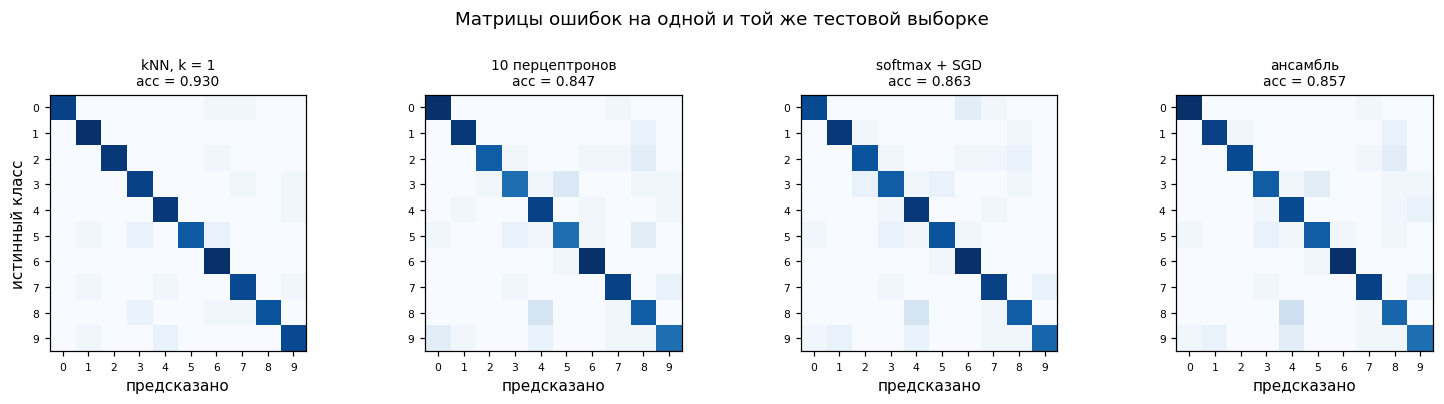

In [12]:
preds = {'kNN, k = 1': pred_knn, '10 перцептронов': pred_argmax,
         'softmax + SGD': pred_soft, 'ансамбль': pred_ens}
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, (name, p) in zip(axes, preds.items()):
    cm = confusion_matrix(y_te, p)
    ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name}\nacc = {np.mean(p == y_te):.3f}', fontsize=9)
    ax.set_xlabel('предсказано')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.tick_params(labelsize=7)
axes[0].set_ylabel('истинный класс')
fig.suptitle('Матрицы ошибок на одной и той же тестовой выборке', y=1.03)
plt.tight_layout()
plt.show()

In [13]:
agree = pd.DataFrame(index=list(preds), columns=list(preds), dtype=float)
for a, pa in preds.items():
    for b, pb in preds.items():
        agree.loc[a, b] = float(np.mean(pa == pb))
print('доля совпадающих предсказаний между моделями:')
print(agree.round(3).to_string())

hard = np.array([sum(p[i] != y_te[i] for p in preds.values()) for i in range(len(y_te))])
print(f'\nобъектов, на которых ошиблись все четыре модели: {(hard == 4).sum()}')
print(f'объектов, на которых не ошибся никто: {(hard == 0).sum()} из {len(y_te)}')

доля совпадающих предсказаний между моделями:
                 kNN, k = 1  10 перцептронов  softmax + SGD  ансамбль
kNN, k = 1            1.000            0.837          0.863     0.863
10 перцептронов       0.837            1.000          0.913     0.937
softmax + SGD         0.863            0.913          1.000     0.940
ансамбль              0.863            0.937          0.940     1.000

объектов, на которых ошиблись все четыре модели: 10
объектов, на которых не ошибся никто: 238 из 300


Модели перцептронного семейства согласуются друг с другом на $91 \ldots 94\%$
объектов, а с kNN только на $84 \ldots 86\%$. Ошибки у линейных моделей общие, а
у kNN свои. Все четыре модели ошиблись одновременно лишь на 10 объектах из 300,
и ни одна не ошиблась на 238.

Отсюда следует, что смешивать стоило бы не однотипные перцептроны, а модели
разных семейств: объединение kNN с линейным классификатором дало бы больше, чем
ансамбль из пятнадцати перцептронов.

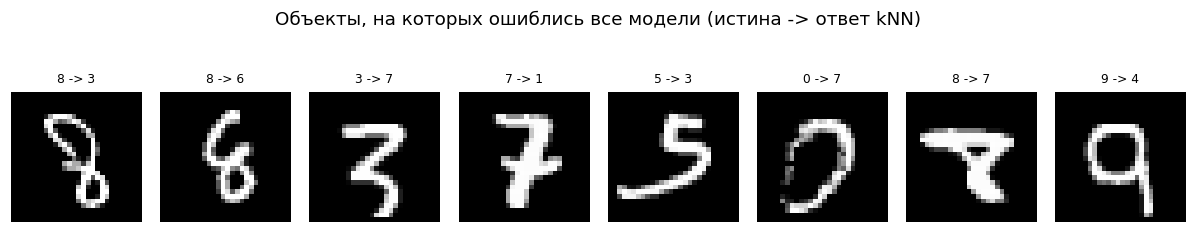

In [14]:
idx = np.flatnonzero(hard == 4)[:8]
fig, axes = plt.subplots(1, 8, figsize=(11, 1.8))
for ax, j in zip(axes, idx):
    ax.imshow(X_te_img[j], cmap='gray')
    ax.set_title(f'{y_te[j]} -> {pred_knn[j]}', fontsize=8)
    ax.axis('off')
fig.suptitle('Объекты, на которых ошиблись все модели (истина -> ответ kNN)', y=1.15)
plt.tight_layout()
plt.show()

Объекты, на которых ошиблись все четыре модели, - действительно спорные
написания: цифры с нетипичным наклоном, разорванными или, наоборот, замкнутыми
петлями. Ни одна из рассмотренных моделей такие случаи не разбирает, поскольку
все они опираются на прямое сравнение яркостей пикселей.